Stock Selection & Data Import

In [45]:
stock_files = ["INFY.csv", "RELIANCE.csv", "TCS.csv", "HDFC_BANK.csv", "ITC.csv", "TATA_MOTORS.csv"]
dataframes = []

for file in stock_files:
    symbol = file.replace('.csv', '')
    df = pd.read_csv(file)


    print(f"\n{file} HEAD:")
    print(df.head())


    if 'Date' not in df.columns:
        df.columns = ['Date', 'Close']

    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')


    df.dropna(subset=['Date'], inplace=True)


    df['Date'] = df['Date'].dt.normalize()

    df['Symbol'] = symbol
    df = df[['Date', 'Close', 'Symbol']]
    dataframes.append(df)


    combined_df = pd.concat(dataframes).sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    combined_df['Close'] = combined_df['Close'].fillna(method='ffill')

    combined_df['Close'] = combined_df['Close'].fillna(method='ffill')




INFY.csv HEAD:
                  Date   Close
0  01/01/2020 15:30:00  736.85
1  02/01/2020 15:30:00  734.70
2  03/01/2020 15:30:00  746.00
3  06/01/2020 15:30:00  738.85
4  07/01/2020 15:30:00  727.90

RELIANCE.csv HEAD:
            Unnamed: 0 Unnamed: 1
0                 Date      Close
1  01/01/2020 15:30:00     747.71
2  02/01/2020 15:30:00     760.44
3  03/01/2020 15:30:00     761.36
4  06/01/2020 15:30:00      743.7

TCS.csv HEAD:
                  Date    Close
0  01/01/2020 15:30:00  2167.60
1  02/01/2020 15:30:00  2157.65
2  03/01/2020 15:30:00  2200.65
3  06/01/2020 15:30:00  2200.45
4  07/01/2020 15:30:00  2205.85

HDFC_BANK.csv HEAD:
                  Date    Close
0  01/01/2020 15:30:00  1278.60
1  02/01/2020 15:30:00  1286.75
2  03/01/2020 15:30:00  1268.40
3  06/01/2020 15:30:00  1240.95
4  07/01/2020 15:30:00  1260.60

ITC.csv HEAD:
                  Date   Close
0  01/01/2020 15:30:00  238.10
1  02/01/2020 15:30:00  239.85
2  03/01/2020 15:30:00  238.50
3  06/01/2020 1

<ipython-input-45-a07e521a6bc2>:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
<ipython-input-45-a07e521a6bc2>:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_df['Close'] = combined_df['Close'].fillna(method='ffill')
<ipython-input-45-a07e521a6bc2>:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_df['Close'] = combined_df['Close'].fillna(method='ffill')


Data Preprocessing

In [21]:

combined_df['Close'] = combined_df['Close'].fillna(method='ffill')

from statsmodels.tsa.stattools import adfuller

def check_stationarity(stock_symbol):
    series = combined_df[combined_df['Symbol'] == stock_symbol]['Close']
    result = adfuller(series)
    print(f"ADF Statistic for {stock_symbol}: {result[0]}")
    print(f"p-value: {result[1]}")
    return result[1]

check_stationarity("INFY")

ADF Statistic for INFY: -1.711954025578753
p-value: 0.4249641661958422


<ipython-input-21-3eb2897b9785>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_df['Close'] = combined_df['Close'].fillna(method='ffill')


np.float64(0.4249641661958422)

Forecasting (Using Prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6gmde399/_lerwoiw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6gmde399/nu17no86.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=21764', 'data', 'file=/tmp/tmp6gmde399/_lerwoiw.json', 'init=/tmp/tmp6gmde399/nu17no86.json', 'output', 'file=/tmp/tmp6gmde399/prophet_model4roypic3/prophet_model-20250512203119.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:31:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:31:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


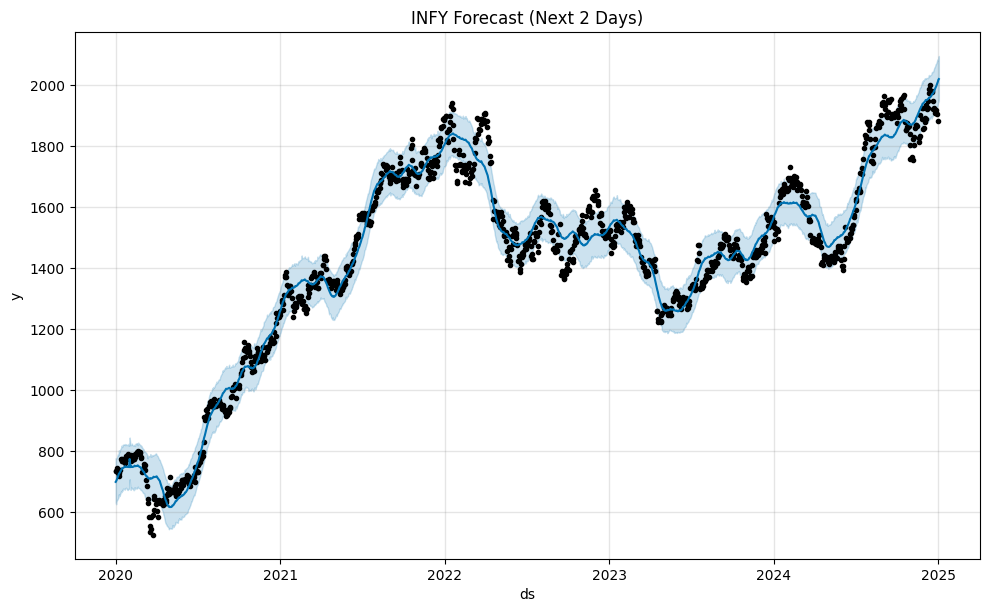

In [22]:
from prophet import Prophet
import matplotlib.pyplot as plt

infy_df = combined_df[combined_df['Symbol'] == 'INFY'][['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

model = Prophet()
model.fit(infy_df)

future = model.make_future_dataframe(periods=2)
forecast = model.predict(future)

model.plot(forecast)
plt.title("INFY Forecast (Next 2 Days)")
plt.show()


 Volatility & Trend Analysis

In [35]:
import numpy as np

combined_df['Close'] = pd.to_numeric(combined_df['Close'], errors='coerce')

combined_df.dropna(subset=['Close'], inplace=True)

combined_df = combined_df[combined_df['Close'] > 0]

combined_df['LogReturn'] = combined_df.groupby('Symbol')['Close'].transform(
    lambda x: np.log(x) - np.log(x.shift(1))
)

combined_df[['Date', 'Symbol', 'Close', 'LogReturn']].head()


,Date,Symbol,Close,LogReturn
0,2020-01-01,HDFC_BANK,1278.60,NaN
1,2020-01-02,HDFC_BANK,1286.75,0.006354
2,2020-01-03,HDFC_BANK,1268.40,-0.014363
3,2020-01-06,HDFC_BANK,1240.95,-0.021879
4,2020-01-07,HDFC_BANK,1260.60,0.015711


Portfolio Allocation Strategy

Forecast-Based Allocation (Simple)

In [36]:

predicted_returns = {
    'INFY': 0.8,
    'RELIANCE': 1.5,
    'TCS': 0.6,
}

capital = 10_00_000
weights = {k: v / sum(predicted_returns.values()) for k, v in predicted_returns.items()}
allocations = {k: v * capital for k, v in weights.items()}
print(allocations)


{'INFY': 275862.0689655172, 'RELIANCE': 517241.37931034487, 'TCS': 206896.55172413794}


Volatility-Aware Sizing

In [38]:
import numpy as np

combined_df['Volatility'] = combined_df.groupby('Symbol')['LogReturn'].transform(
    lambda x: x.rolling(window=10).std()
)

latest_vol = combined_df.dropna(subset=['Volatility']).groupby('Symbol')['Volatility'].last()

inv_vol = 1 / latest_vol

weights = inv_vol / inv_vol.sum()

capital = 1_000_000
allocations = (weights * capital).to_dict()

print("Weights (inverse volatility):")
print(weights)
print("\nCapital Allocation:")
print(allocations)


Weights (inverse volatility):
Symbol
HDFC_BANK      0.173194
INFY           0.234658
ITC            0.190243
RELIANCE       0.143893
TATA_MOTORS    0.096705
TCS            0.161307
Name: Volatility, dtype: float64

Capital Allocation:
{'HDFC_BANK': 173193.83815703235, 'INFY': 234657.96926556507, 'ITC': 190243.10918811578, 'RELIANCE': 143892.89553370088, 'TATA_MOTORS': 96705.39564064732, 'TCS': 161306.79221493853}


 Model Evaluation

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np


actual = [2875.45, 2890.10]
predicted = [2870.00, 2895.50]


mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(actual, predicted)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


RMSE: 5.42505760338077
MAPE: 0.0018819014840689152


Visualizations

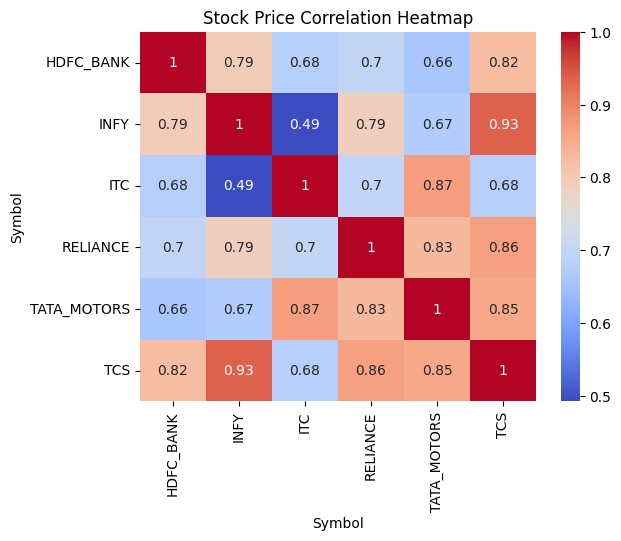

In [43]:
import seaborn as sns

pivoted = combined_df.pivot(index='Date', columns='Symbol', values='Close')
corr = pivoted.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Stock Price Correlation Heatmap")
plt.show()
